Initial count: 20
Weekly count: 1
Combined: 21
21


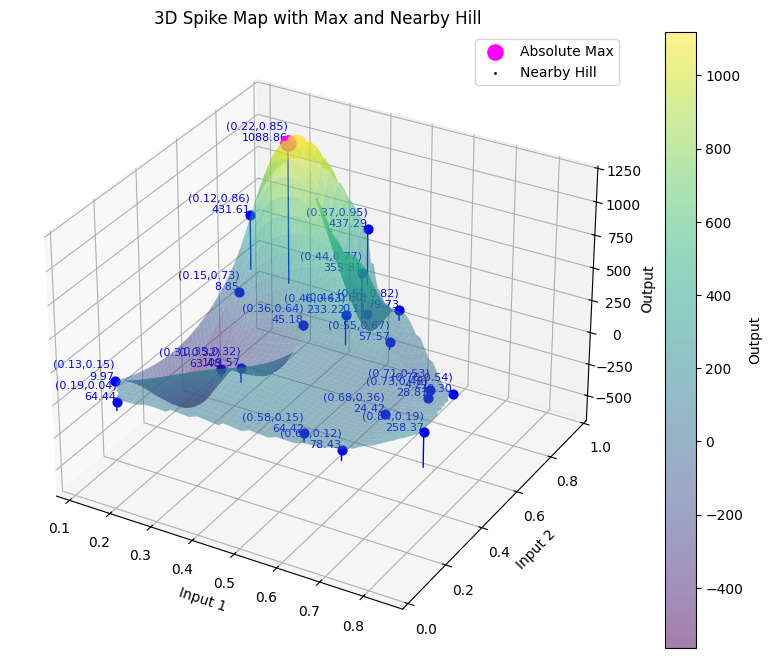

Initial count: 20
Weekly count: 2
Combined: 22
22


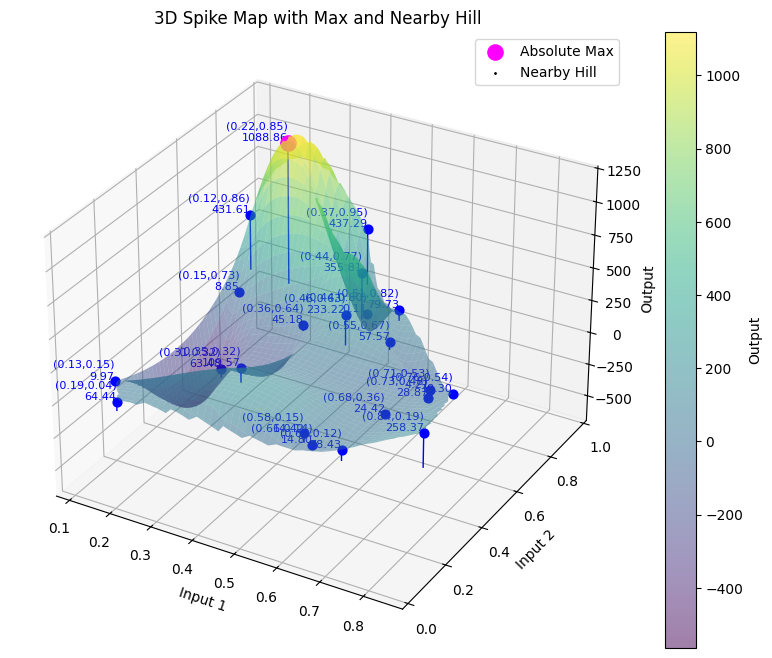

Initial count: 20
Weekly count: 3
Combined: 23
23


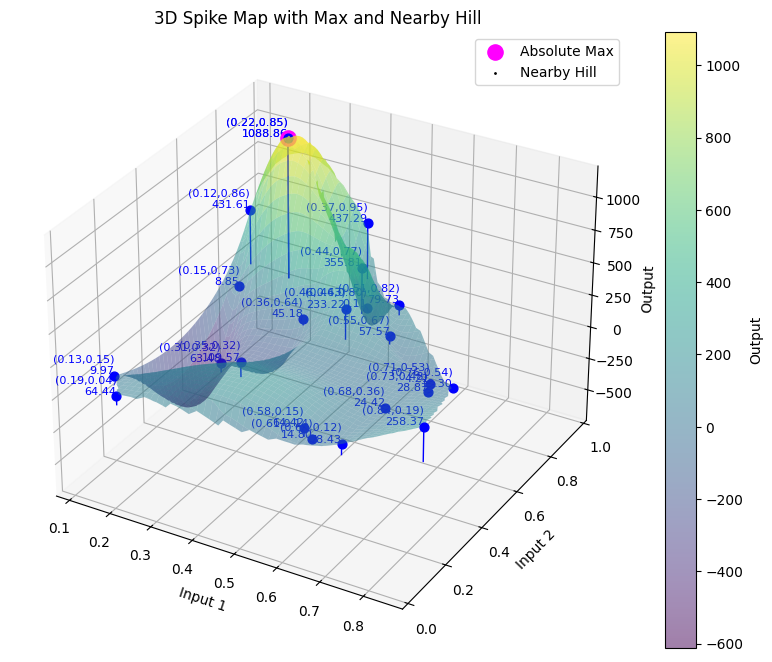

Initial count: 20
Weekly count: 4
Combined: 24
24


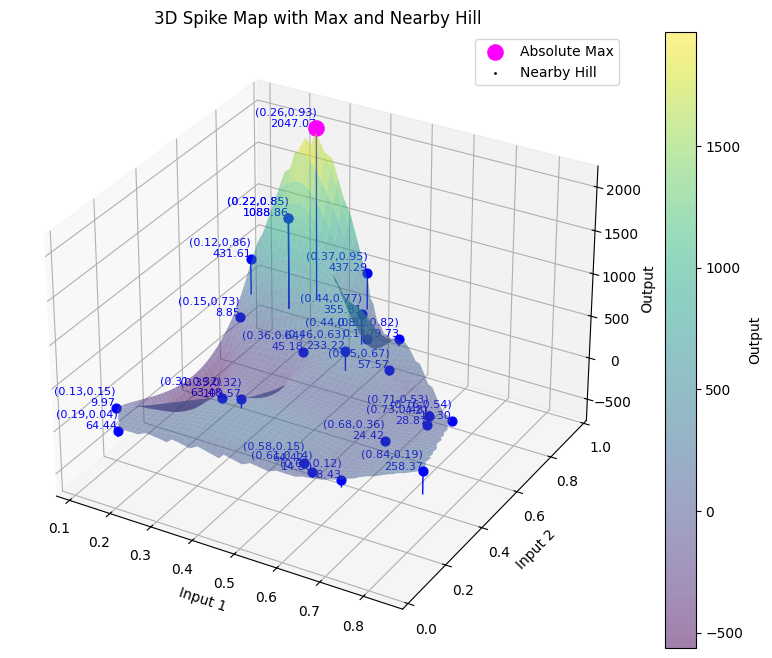

Initial count: 20
Weekly count: 5
Combined: 25
25


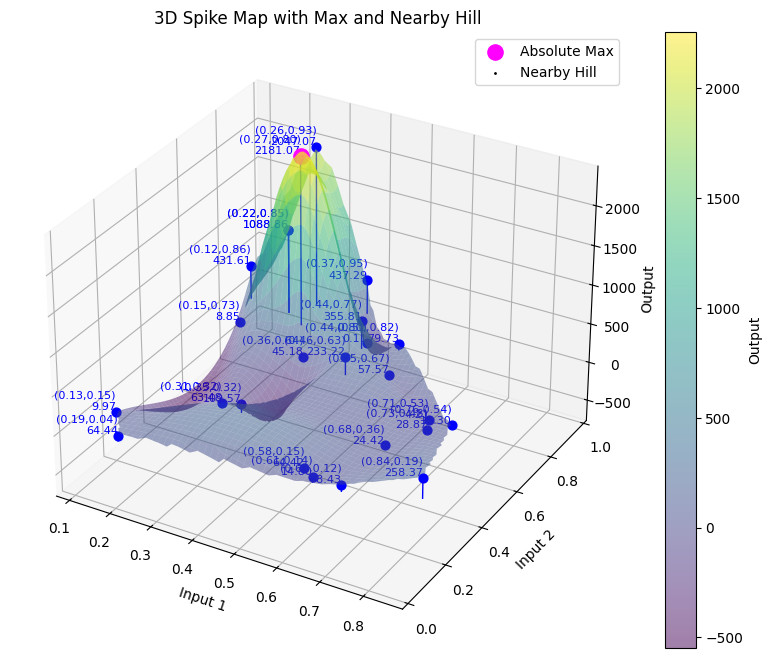

Initial count: 20
Weekly count: 6
Combined: 26
26


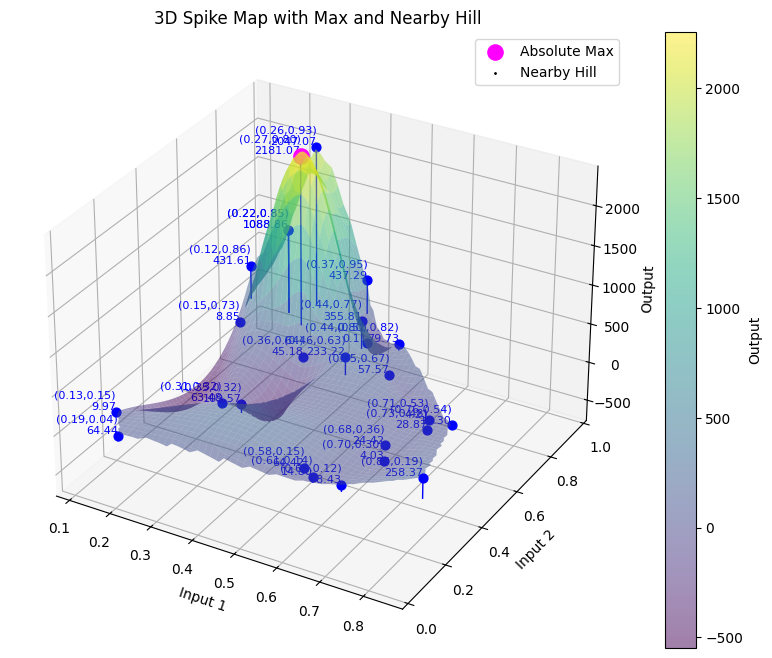

Initial count: 20
Weekly count: 7
Combined: 27
27


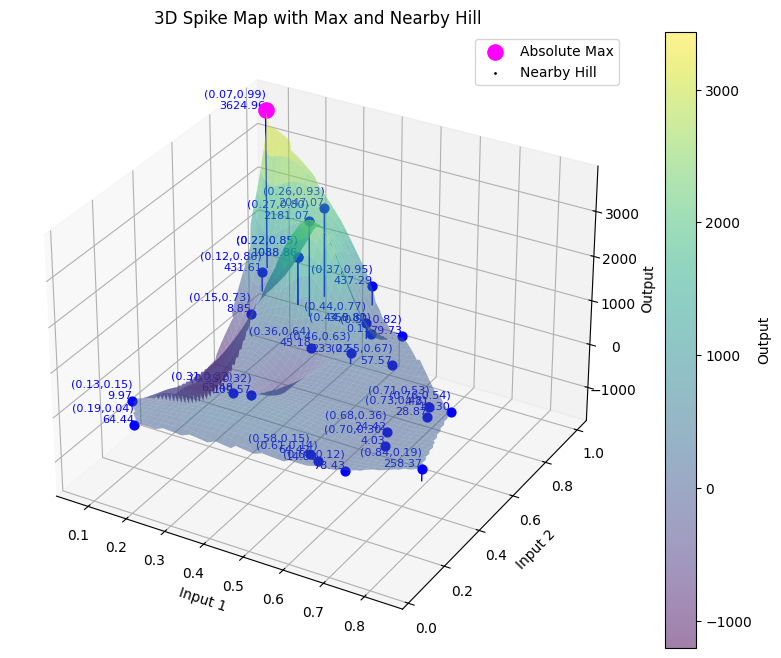

Initial count: 20
Weekly count: 8
Combined: 28
28


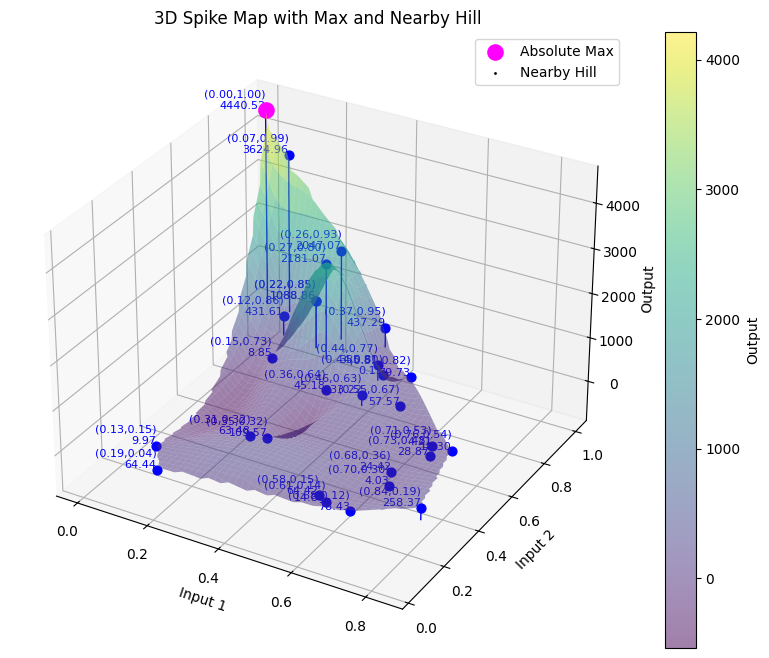

Initial count: 20
Weekly count: 9
Combined: 29
29


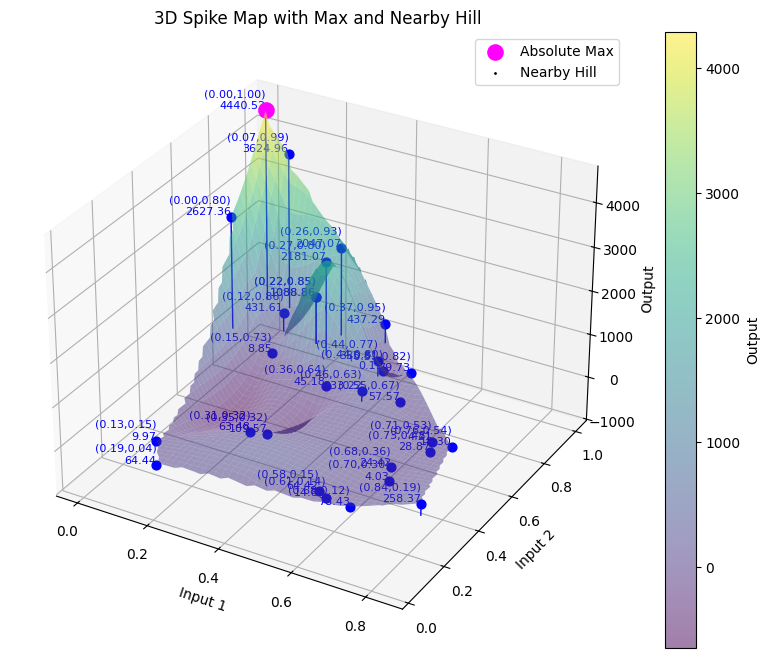

Initial count: 20
Weekly count: 10
Combined: 30
30


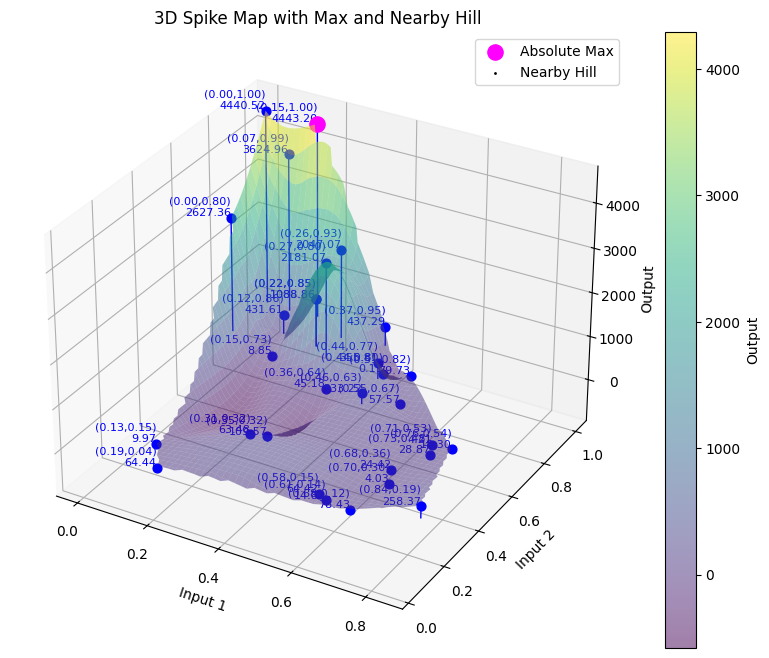

Initial count: 20
Weekly count: 11
Combined: 31
31


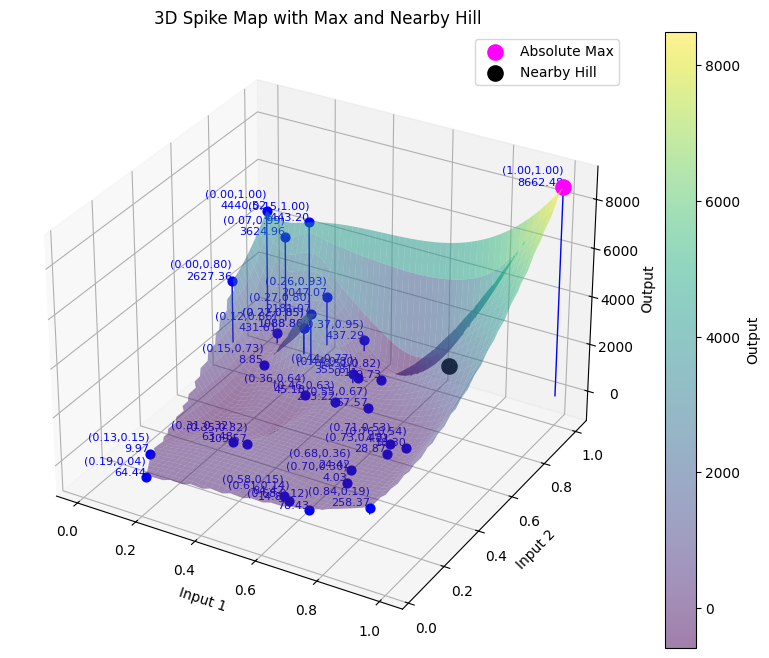

Initial count: 20
Weekly count: 12
Combined: 32
32


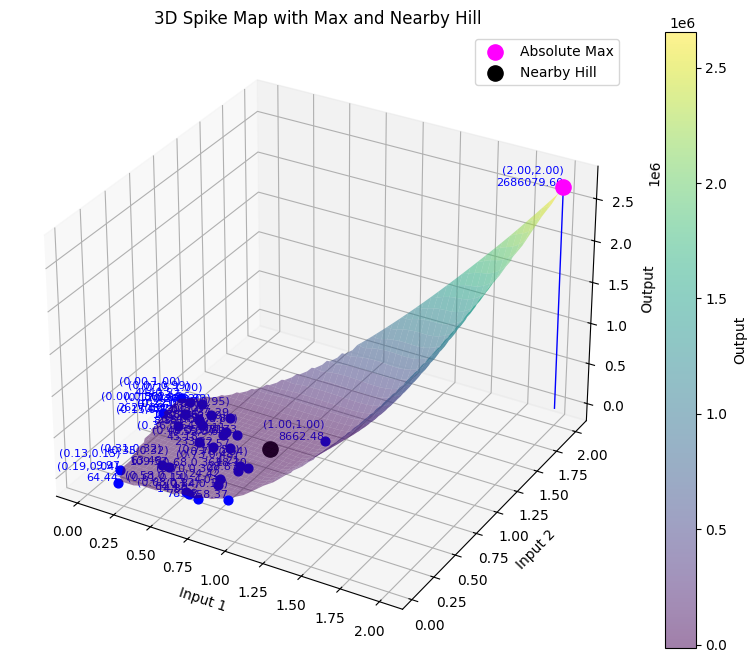

Initial count: 20
Weekly count: 13
Combined: 33
33


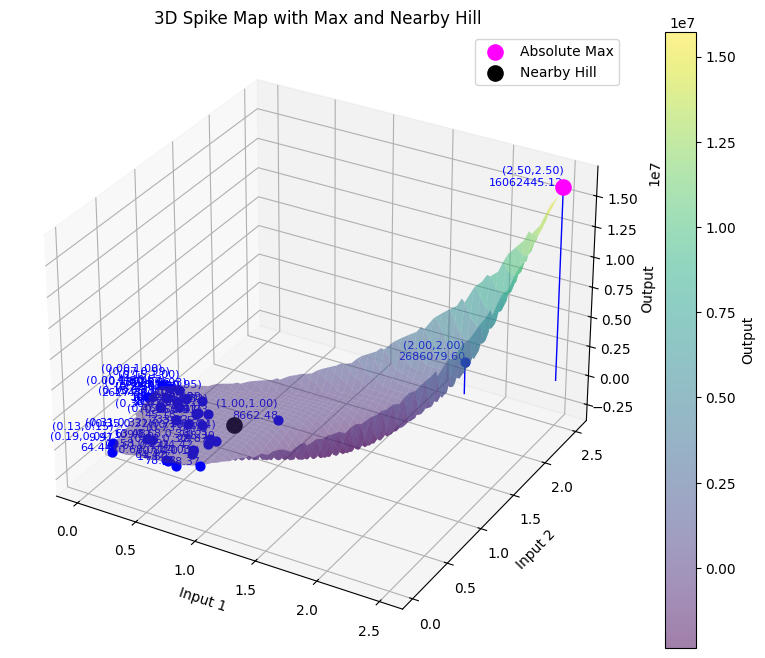

In [6]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from scipy.interpolate import griddata
import numpy as np
from scripts.utils.read_inputs_outputs import generate_data
weekMax = 13
for week in range(1, weekMax+1) :

    functionNo = 5
    weekNo = week
    X, y = generate_data(functionNo, weekNo)

    X_train = X
    y_train = y

    x1 = X_train[:, 0]
    x2 = X_train[:, 1]
    y = y_train

# Grid for surface interpolation
    xi = np.linspace(x1.min(), x1.max(), 100)
    yi = np.linspace(x2.min(), x2.max(), 100)
    XI, YI = np.meshgrid(xi, yi)
    ZI = griddata((x1, x2), y, (XI, YI), method='cubic')

    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')

# Plot interpolated surface
    surf = ax.plot_surface(XI, YI, ZI, cmap='viridis', alpha=0.5)

# Plot spikes
    for xi_pt, yi_pt, zi_pt in zip(x1, x2, y):
        ax.plot([xi_pt, xi_pt], [yi_pt, yi_pt], [0, zi_pt], color="blue", lw=1)

# Plot all points as dots and annotate
    for xi_pt, yi_pt, zi_pt in zip(x1, x2, y):
        ax.scatter(xi_pt, yi_pt, zi_pt, color="blue", s=40)
        ax.text(xi_pt, yi_pt, zi_pt, f"({xi_pt:.2f},{yi_pt:.2f})\n{zi_pt:.2f}",
            fontsize=8, color='blue', ha='right', va='bottom')

# Magenta dot: max output
    max_idx = np.argmax(y)
    ax.scatter(x1[max_idx], x2[max_idx], y[max_idx], color="magenta", s=120, label='Absolute Max')

# Yellow dot: nearby hill (your suggested "hill point")
    hill_x1, hill_x2 = 0.76, 0.78  # example from your message
    hill_y = griddata((x1, x2), y, [(hill_x1, hill_x2)], method='cubic')[0]
    ax.scatter(hill_x1, hill_x2, hill_y, color="black", s=120, label='Nearby Hill')

# Labels and legend
    ax.set_xlabel('Input 1')
    ax.set_ylabel('Input 2')
    ax.set_zlabel('Output')
    ax.set_title('3D Spike Map with Max and Nearby Hill')
    ax.legend()
    plt.colorbar(surf, label='Output')

    plt.show()


In [1]:
import numpy as np
import pandas as pd
import umap
import plotly.express as px
import plotly.graph_objects as go
from ipywidgets import HBox, VBox


# -------------------------
#  Compute 2D UMAP
# -------------------------
reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(X)

df = pd.DataFrame({
    'UMAP1': embedding[:,0],
    'UMAP2': embedding[:,1],
    'Output': y,
    'Index': np.arange(len(y))
})


scatter_fig = go.FigureWidget(px.scatter(
    df, x='UMAP1', y='UMAP2',
    color='Output',
    color_continuous_scale='Viridis',
    hover_data={'Index': True, 'UMAP1':True, 'UMAP2':True, 'Output':True},
    title="8D Features UMAP"
))
scatter_fig.update_layout(width=600, height=500)

feature_names = [f"F{i}" for i in range(X.shape[1])]
bars = []

for i in range(4):
    fig = go.FigureWidget(
        data=[go.Bar(x=feature_names, y=[0]*X.shape[1], text=[0]*X.shape[1], textposition='auto')],
        layout=go.Layout(title=f"Sample {i}", yaxis=dict(range=[0,1.1]), width=300, height=400)
    )
    bars.append(fig)

bars_box = HBox(bars)


selected_samples = [0, 1, 2, 3]  # placeholders

def update_bars(trace, points, selector):
    if len(points.point_inds) > 0:
        idx = points.point_inds[0]
        # rotate samples
        selected_samples.insert(0, selected_samples.pop())
        selected_samples[0] = idx
        for i, bar_fig in enumerate(bars):
            bar_fig.data[0].y = X[selected_samples[i]]
            # include output as a label at the top
            bar_fig.data[0].text = [f"{v:.2f}" for v in X[selected_samples[i]]]
            bar_fig.update_layout(title=f"Sample {selected_samples[i]}, Output={y[selected_samples[i]]:.3f}")

scatter_fig.data[0].on_click(update_bars)


VBox([scatter_fig, bars_box])
from IPython.display import display
from ipywidgets import HBox, VBox

bars_box = HBox(bars)  # arrange bar charts side by side
display(VBox([scatter_fig, bars_box]))  # scatter on top, bars below


NameError: name 'X' is not defined

Initial count: 10
Weekly count: 12
Combined: 22
22
Using 22 points in the slice


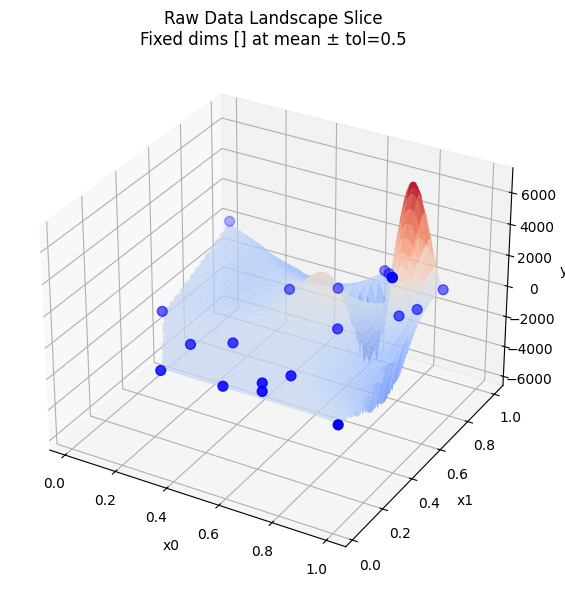

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scripts.utils.read_inputs_outputs import generate_data
functionNo = 2
weekNo = 13
X, y = generate_data(functionNo, weekNo)
d1, d2 = 0, 1
D = X.shape[1]

# FIX: automatically determine fixed dimensions
fixed_dims = [d for d in range(D) if d not in (d1, d2)]

# Fix remaining dims at their mean
fixed_values = X[:, fixed_dims].mean(axis=0)

tol = 0.5  # Increase for higher D due to sparsity

# Select points near the slice
mask = np.all(
    np.abs(X[:, fixed_dims] - fixed_values) < tol,
    axis=1
)

X2 = X[mask][:, [d1, d2]]
y2 = y[mask]

print(f"Using {len(y2)} points in the slice")

if len(y2) < 5:
    raise ValueError(
        "Not enough points in slice; increase tolerance or choose different dims."
    )

# -------------------
# Create grid for interpolation
# -------------------
xi = np.linspace(X2[:, 0].min(), X2[:, 0].max(), 100)
yi = np.linspace(X2[:, 1].min(), X2[:, 1].max(), 100)
XI, YI = np.meshgrid(xi, yi)

# Interpolate raw y values on grid
ZI = griddata(X2, y2, (XI, YI), method="cubic")

# -------------------
# Plot the surface + raw points
# -------------------
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

# Surface plot (may contain NaNs if sparse)
ax.plot_surface(
    XI, YI, ZI,
    cmap="coolwarm",
    alpha=0.8,
    edgecolor="none"
)

# Scatter raw points
ax.scatter(
    X2[:, 0], X2[:, 1], y2,
    color="blue",
    s=50
)

ax.set_xlabel(f"x{d1}")
ax.set_ylabel(f"x{d2}")
ax.set_zlabel("y")
ax.set_title(
    f"Raw Data Landscape Slice\n"
    f"Fixed dims {fixed_dims} at mean ± tol={tol}"
)

plt.tight_layout()
plt.show()


In [8]:
# INITIALISE  the scripts in order to run them from repo 
# ==============================================================
import os
import sys


current_dir = os.getcwd()
repo_root = current_dir

while "scripts" not in os.listdir(repo_root):
    parent = os.path.abspath(os.path.join(repo_root, ".."))
    if parent == repo_root:  # reached filesystem root
        raise FileNotFoundError("Cannot find 'scripts' folder in parent directories")
    repo_root = parent

# Add repo root to Python path
if repo_root not in sys.path:
    sys.path.append(repo_root)

print("!Added repo root to sys.path:", repo_root)

import scripts

KeyboardInterrupt: 